In [ ]:
import os
from itertools import product
if os.getcwd().endswith("ablations"):
    os.chdir("..") # change to repo root
import glob
import numpy as np

# heatmap visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors

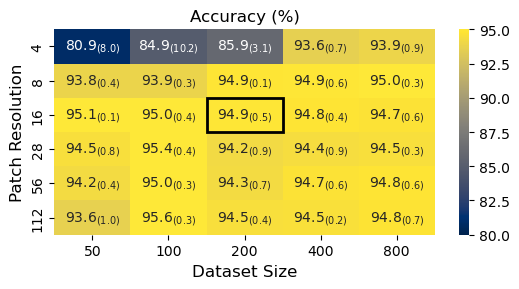

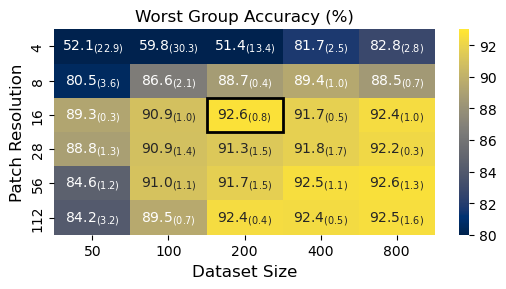

In [ ]:
prs = [4, 8, 16, 28, 56, 112]
dss = [50, 100, 200, 400, 800]

n_seeds = np.zeros((len(prs), len(dss)))
n_paths = np.zeros((len(prs), len(dss)))
mean_acc = np.zeros((len(prs), len(dss)))
std_acc = np.zeros((len(prs), len(dss)))
mean_wga = np.zeros((len(prs), len(dss)))
std_wga = np.zeros((len(prs), len(dss)))

for config in product(range(len(prs)), range(len(dss))):
    i, j = config
    pr, ds = prs[i], dss[j]
    target_path = f"ablations/dspr/ours_ds{ds}_pr{pr}_waterbird_wom_resnet_seed*"
    all_result_paths = glob.glob(f"{target_path}/test_accuracies.txt")
    accs, wgas = [], []
    for result_path in all_result_paths:
        with open(result_path, "r") as f:
            for line in f:
                if "Worst Group Accuracy:" in line:
                    wgas.append(float(line.split("Worst Group Accuracy:")[-1].replace("%", "").strip()))
                if "Overall Accuracy:" in line:
                    accs.append(float(line.split("Overall Accuracy:")[-1].replace("%", "").strip()))
    mean_acc[i, j] = np.mean(accs)
    std_acc[i, j] = np.std(accs)
    mean_wga[i, j] = np.mean(wgas)
    std_wga[i, j] = np.std(wgas)
    n_seeds[i, j] += len(accs)
    n_paths[i, j] += len(glob.glob(target_path))

figsize = (5.5, 3)

# # plot number of seeds heatmap
# plt.figure(figsize=figsize)
# sns.heatmap(n_seeds, annot=True, fmt=".0f", xticklabels=dss, yticklabels=prs, cmap="Blues")
# plt.xlabel("Dataset Size")
# plt.ylabel("Patch Resolution")
# plt.title("Number of Seeds with Results")
# plt.show()

# # plot number of result paths heatmap
# plt.figure(figsize=figsize)
# sns.heatmap(n_paths, annot=True, fmt=".0f", xticklabels=dss, yticklabels=prs, cmap="Greens")
# plt.xlabel("Dataset Size")
# plt.ylabel("Patch Resolution")  
# plt.title("Number of Result Paths Found")
# plt.show()

# target = np.array(mcolors.to_rgb(plt.get_cmap("Set2").colors[0]))
# start = 1 - 0.05 * (1 - target)
# cmap = mcolors.LinearSegmentedColormap.from_list(
#     "C0map",
#     [start, target]
# )

# plot overall accuracy heatmap
plt.figure(figsize=figsize)
annot = np.vectorize(lambda m, s: rf"${m:.1f}_{{({s:.1f})}}$")(
    mean_acc, std_acc
)
ax = sns.heatmap(mean_acc, annot=annot, fmt="", xticklabels=dss, yticklabels=prs, cmap="cividis", vmin=80, vmax=95)
rect = Rectangle((2, 2), 1, 1, fill=False, edgecolor='black', lw=2)
ax.add_patch(rect)
plt.xlabel("Dataset Size", fontsize=12)
plt.ylabel("Patch Resolution", fontsize=12)  
plt.title("Accuracy (%)")
plt.tight_layout()
plt.savefig("plots/ablation_ds_pr_acc.pdf", bbox_inches="tight", pad_inches=0.1)
plt.show()

# target = np.array(mcolors.to_rgb(plt.get_cmap("Set2").colors[1]))
# start = 1 - 0.05 * (1 - target)
# cmap = mcolors.LinearSegmentedColormap.from_list(
#     "C1map",
#     [start, target]
# )

# plot worst group accuracy heatmap
plt.figure(figsize=figsize)
annot = np.vectorize(lambda m, s: rf"${m:.1f}_{{({s:.1f})}}$")(
    mean_wga, std_wga
)
ax = sns.heatmap(mean_wga, annot=annot, fmt="", xticklabels=dss, yticklabels=prs, cmap="cividis", vmin=80, vmax=93)
rect = Rectangle((2, 2), 1, 1, fill=False, edgecolor='black', lw=2)
ax.add_patch(rect)
plt.xlabel("Dataset Size", fontsize=12)
plt.ylabel("Patch Resolution", fontsize=12)  
plt.title("Worst Group Accuracy (%)")
plt.tight_layout()
plt.savefig("plots/ablation_ds_pr_wga.pdf", bbox_inches="tight", pad_inches=0.1)
plt.show()